In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
import matplotlib.pyplot as plt

In [2]:
df_clean = pd.read_csv('power_daily_clean.csv', index_col='dt', parse_dates=True)
values = df_clean.values

In [3]:
scaler_gru = MinMaxScaler(feature_range=(0, 1))
scaled_val = scaler_gru.fit_transform(values)

In [4]:
def create_gru_ds(dataset, look_back=30):
    X, Y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        Y.append(dataset[i, 0])
    return np.array(X), np.array(Y)

X_all, y_all = create_gru_ds(scaled_val, 30)

In [5]:
train_size = int(len(X_all) * 0.8)
X_train, X_test = X_all[:train_size], X_all[train_size:]
y_train, y_test = y_all[:train_size], y_all[train_size:]

In [6]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(f"Dữ liệu đã sẵn sàng: X_train shape = {X_train.shape}")

Dữ liệu đã sẵn sàng: X_train shape = (1129, 30, 1)


In [7]:
model_gru = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    GRU(units=50, return_sequences=False),
    Dropout(0.2),

    Dense(units=1)
])

model_gru.compile(optimizer='adam', loss='mean_squared_error')
model_gru.summary()

c:\Users\admin\Desktop\visual studio code bt\demo\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Đang cho GRU học thói quen dùng điện...")
history_gru = model_gru.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Đang cho GRU học thói quen dùng điện...
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0249
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0111
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0112
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0111
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0110
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0109
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0108
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0108


In [9]:
predict_gru = model_gru.predict(X_test)
predict_gru_real = scaler_gru.inverse_transform(predict_gru)
y_test_real = scaler_gru.inverse_transform(y_test.reshape(-1, 1))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


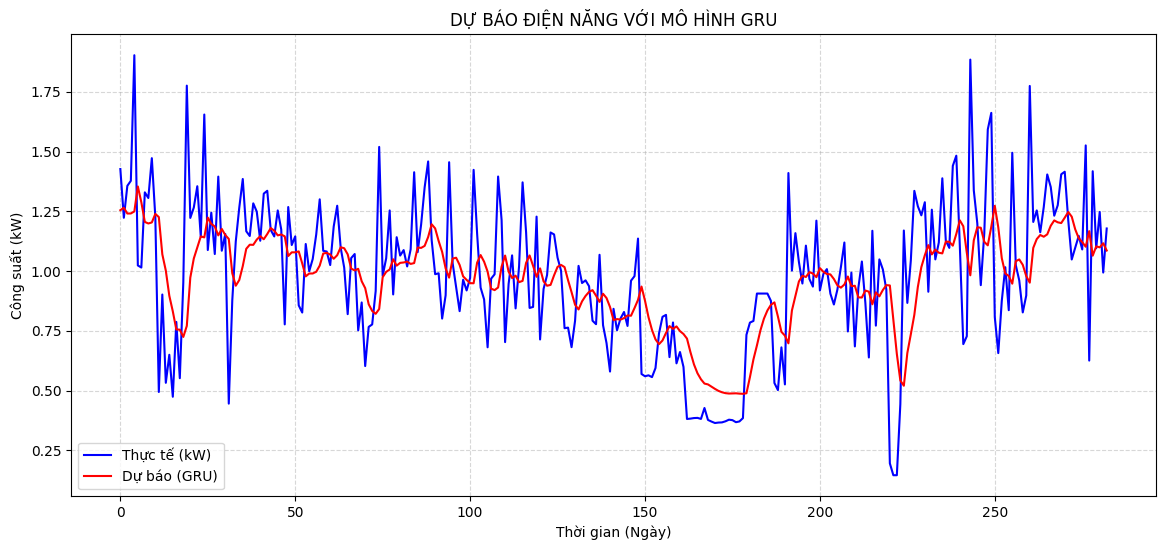

In [14]:
plt.style.use('default') 
plt.figure(figsize=(14, 6))
plt.plot(y_test_real, color='blue', label='Thực tế (kW)')
plt.plot(predict_gru_real, color='red', label='Dự báo (GRU)')
plt.title('DỰ BÁO ĐIỆN NĂNG VỚI MÔ HÌNH GRU')
plt.xlabel('Thời gian (Ngày)')
plt.ylabel('Công suất (kW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [25]:

model_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,905 (273.07 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,604 (182.05 KB)